# Task
Analyze Nifty 50 (^NSEI) historical daily data for at least 12-15 years using yfinance to predict volatility regimes. This involves downloading data, calculating returns and volatility, defining volatility regimes (high/low), engineering a comprehensive set of features (momentum, trend, technical indicators, volume, risk, and lagged features), preparing the data, training Logistic Regression, Random Forest, Gradient Boosting, and XGBoost models, evaluating their performance with various metrics (accuracy, precision, recall, F1, confusion matrix, ROC-AUC), and visualizing the results. The final output should identify the best-performing model, its key performance metrics, and a list of the most important predictive features, along with a summary of the machine learning pipeline and insights.

## Import Libraries

### Subtask:
Import all necessary Python libraries and modules, including pandas, numpy, matplotlib, seaborn, yfinance, scikit-learn (StandardScaler, train_test_split, RandomForestClassifier, GradientBoostingClassifier, LogisticRegression, confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve), xgboost, and ta.


**Reasoning**:
The subtask requires importing a list of specific Python libraries and modules for data manipulation, visualization, financial data, and machine learning. This code block will perform all the necessary imports.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
import xgboost as xgb
import ta

print("All necessary libraries and modules have been imported.")

ModuleNotFoundError: No module named 'ta'

**Reasoning**:
The previous code block failed because the 'ta' library was not found. To resolve this `ModuleNotFoundError`, the 'ta' library needs to be installed before it can be imported. This new code block will install the missing library.



In [ ]:
import sys
!{sys.executable} -m pip install ta

print("The 'ta' library has been installed.")

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=9a38594d8a1170feb2a8eb36d8ebafc67cb91cd214f4e3fc5863cb9a56a4a956
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta
The 'ta' library has been installed.


**Reasoning**:
The 'ta' library has now been installed. The next step is to re-execute the import block to successfully import all specified libraries and modules, completing the subtask.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve
import xgboost as xgb
import ta

print("All necessary libraries and modules have been imported.")

All necessary libraries and modules have been imported.


## Download Market Data

### Subtask:
Download at least 12-15 years of historical daily data for the Nifty 50 (^NSEI) using yfinance. Extract 'Open', 'High', 'Low', 'Close', 'Adj Close', and 'Volume' columns. Sort the data by date in ascending order.


**Reasoning**:
The subtask requires downloading Nifty 50 historical data for at least 12-15 years. This involves defining the ticker, calculating the appropriate start date, downloading the data using `yfinance`, selecting the specified columns, and ensuring the data is sorted by date.



In [ ]:
import datetime

# 1. Define the ticker symbol for Nifty 50
ticker = '^NSEI'

# 2. Calculate a start date that is at least 15 years prior to the current date
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=15*365) # At least 15 years

print(f"Downloading data for {ticker} from {start_date} to {end_date}")

# 3. Use yf.download() to download the historical daily data
nifty_data = yf.download(ticker, start=start_date, end=end_date)

# 4. Select the columns 'Open', 'High', 'Low', 'Close', 'Adj Close', and 'Volume'
required_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
nifty_data = nifty_data[required_columns]

# 5. Ensure the DataFrame is sorted by its index (date) in ascending order
# yfinance typically returns data sorted this way, but we ensure it.
nifty_data.sort_index(inplace=True, ascending=True)

print("\nNifty 50 historical data downloaded and processed successfully.")
print("First 5 rows of the data:")
print(nifty_data.head())
print("\nData Info:")
nifty_data.info()

/tmp/ipykernel_329/1208651559.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


KeyError: "['Adj Close'] not in index"

**Reasoning**:
The previous code failed with a `KeyError` because 'Adj Close' was not found in the downloaded data. This is likely due to `yfinance`'s default `auto_adjust=True` behavior, which adjusts the 'Close' price and removes the 'Adj Close' column. To ensure 'Adj Close' is included as requested by the subtask, `auto_adjust` needs to be explicitly set to `False` in the `yf.download` function call.



In [ ]:
import datetime

# 1. Define the ticker symbol for Nifty 50
ticker = '^NSEI'

# 2. Calculate a start date that is at least 15 years prior to the current date
end_date = datetime.date.today()
start_date = end_date - datetime.timedelta(days=15*365) # At least 15 years

print(f"Downloading data for {ticker} from {start_date} to {end_date}")

# 3. Use yf.download() to download the historical daily data
# Set auto_adjust=False to ensure 'Adj Close' is included in the downloaded data.
nifty_data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

# 4. Select the columns 'Open', 'High', 'Low', 'Close', 'Adj Close', and 'Volume'
required_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
nifty_data = nifty_data[required_columns]

# 5. Ensure the DataFrame is sorted by its index (date) in ascending order
# yfinance typically returns data sorted this way, but we ensure it.
nifty_data.sort_index(inplace=True, ascending=True)

print("\nNifty 50 historical data downloaded and processed successfully.")
print("First 5 rows of the data:")
print(nifty_data.head())
print("\nData Info:")
nifty_data.info()

[*********************100%***********************]  1 of 1 completed


Nifty 50 historical data downloaded and processed successfully.
First 5 rows of the data:
Price              Open         High          Low        Close    Adj Close  \
Ticker            ^NSEI        ^NSEI        ^NSEI        ^NSEI        ^NSEI   
Date                                                                          
2011-03-16  5475.950195  5535.100098  5475.950195  5511.149902  5511.149902   
2011-03-17  5455.399902  5510.049805  5435.299805  5446.649902  5446.649902   
2011-03-18  5475.350098  5483.049805  5366.399902  5373.700195  5373.700195   
2011-03-21  5408.750000  5413.299805  5348.200195  5364.750000  5364.750000   
2011-03-22  5390.850098  5428.149902  5376.149902  5413.850098  5413.850098   

Price      Volume  
Ticker      ^NSEI  
Date               
2011-03-16      0  
2011-03-17      0  
2011-03-18      0  
2011-03-21      0  
2011-03-22      0  

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3676 entries, 2011-03-16 to 2026-03-11
Data columns

**Reasoning**:
The `nifty_data` DataFrame has a MultiIndex for its columns, which can make data access cumbersome. To simplify column referencing, I will flatten the MultiIndex by concatenating the level 0 and level 1 names.



In [ ]:
if isinstance(nifty_data.columns, pd.MultiIndex):
    nifty_data.columns = ['_'.join(col).strip() for col in nifty_data.columns.values]

print("Columns flattened successfully. First 5 rows of the data with new column names:")
print(nifty_data.head())
print("\nData Info with new column names:")
nifty_data.info()

Columns flattened successfully. First 5 rows of the data with new column names:
             Open_^NSEI   High_^NSEI    Low_^NSEI  Close_^NSEI  \
Date                                                             
2011-03-16  5475.950195  5535.100098  5475.950195  5511.149902   
2011-03-17  5455.399902  5510.049805  5435.299805  5446.649902   
2011-03-18  5475.350098  5483.049805  5366.399902  5373.700195   
2011-03-21  5408.750000  5413.299805  5348.200195  5364.750000   
2011-03-22  5390.850098  5428.149902  5376.149902  5413.850098   

            Adj Close_^NSEI  Volume_^NSEI  
Date                                       
2011-03-16      5511.149902             0  
2011-03-17      5446.649902             0  
2011-03-18      5373.700195             0  
2011-03-21      5364.750000             0  
2011-03-22      5413.850098             0  

Data Info with new column names:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3676 entries, 2011-03-16 to 2026-03-11
Data columns (total 6 c

## Create Returns

### Subtask:
Calculate daily returns as the percentage change of the 'Close' price.


**Reasoning**:
The subtask requires calculating daily returns from the 'Close_^NSEI' column. The `pct_change()` method is suitable for this calculation, and the result will be stored in a new column 'Daily_Return' in the `nifty_data` DataFrame.



In [ ]:
nifty_data['Daily_Return'] = nifty_data['Close_^NSEI'].pct_change()

print("Daily returns calculated and added to 'Daily_Return' column.")
print("First 5 rows with 'Daily_Return':")
print(nifty_data.head())

Daily returns calculated and added to 'Daily_Return' column.
First 5 rows with 'Daily_Return':
             Open_^NSEI   High_^NSEI    Low_^NSEI  Close_^NSEI  \
Date                                                             
2011-03-16  5475.950195  5535.100098  5475.950195  5511.149902   
2011-03-17  5455.399902  5510.049805  5435.299805  5446.649902   
2011-03-18  5475.350098  5483.049805  5366.399902  5373.700195   
2011-03-21  5408.750000  5413.299805  5348.200195  5364.750000   
2011-03-22  5390.850098  5428.149902  5376.149902  5413.850098   

            Adj Close_^NSEI  Volume_^NSEI  Daily_Return  
Date                                                     
2011-03-16      5511.149902             0           NaN  
2011-03-17      5446.649902             0     -0.011704  
2011-03-18      5373.700195             0     -0.013394  
2011-03-21      5364.750000             0     -0.001666  
2011-03-22      5413.850098             0      0.009152  


## Compute Volatility

### Subtask:
Calculate rolling volatility for 10-day, 20-day, and 30-day periods using the standard deviation of daily returns.


**Reasoning**:
The subtask requires calculating rolling volatility for 10-day, 20-day, and 30-day periods using the standard deviation of daily returns. I will use the `rolling()` method with `std()` to compute these volatilities and store them in new columns.



In [ ]:
nifty_data['Volatility_10D'] = nifty_data['Daily_Return'].rolling(window=10).std()
nifty_data['Volatility_20D'] = nifty_data['Daily_Return'].rolling(window=20).std()
nifty_data['Volatility_30D'] = nifty_data['Daily_Return'].rolling(window=30).std()

print("Rolling volatilities (10D, 20D, 30D) calculated and added to the DataFrame.")
print("First 5 rows with volatility columns:")
print(nifty_data.head())

Rolling volatilities (10D, 20D, 30D) calculated and added to the DataFrame.
First 5 rows with volatility columns:
             Open_^NSEI   High_^NSEI    Low_^NSEI  Close_^NSEI  \
Date                                                             
2011-03-16  5475.950195  5535.100098  5475.950195  5511.149902   
2011-03-17  5455.399902  5510.049805  5435.299805  5446.649902   
2011-03-18  5475.350098  5483.049805  5366.399902  5373.700195   
2011-03-21  5408.750000  5413.299805  5348.200195  5364.750000   
2011-03-22  5390.850098  5428.149902  5376.149902  5413.850098   

            Adj Close_^NSEI  Volume_^NSEI  Daily_Return  Volatility_10D  \
Date                                                                      
2011-03-16      5511.149902             0           NaN             NaN   
2011-03-17      5446.649902             0     -0.011704             NaN   
2011-03-18      5373.700195             0     -0.013394             NaN   
2011-03-21      5364.750000             0     -0

## Define Volatility Regimes

### Subtask:
Define volatility regimes based on the 20-day rolling volatility. If volatility > median volatility, classify as High Volatility (1); otherwise, classify as Low Volatility (0). Shift the label forward by one period to predict future regimes.


**Reasoning**:
The subtask requires defining volatility regimes based on the 20-day rolling volatility, classifying them as high or low, shifting the label for prediction, and handling resulting NaN values. I will calculate the median, create the 'Volatility_Regime' column, shift it, and then drop rows with NaNs.



In [ ]:
median_volatility_20D = nifty_data['Volatility_20D'].median()

nifty_data['Volatility_Regime'] = (nifty_data['Volatility_20D'] > median_volatility_20D).astype(int)

nifty_data['Volatility_Regime'] = nifty_data['Volatility_Regime'].shift(-1)

# Drop NaN values that resulted from volatility calculations and the regime shift
nifty_data.dropna(inplace=True)

print("Volatility regimes defined, shifted, and NaN values handled.")
print("First 5 rows of the data with 'Volatility_Regime' column:")
print(nifty_data.head())
print("Last 5 rows of the data to check shifted regime:")
print(nifty_data.tail())
print("Info of the DataFrame after dropping NaNs:")
nifty_data.info()


Volatility regimes defined, shifted, and NaN values handled.
First 5 rows of the data with 'Volatility_Regime' column:
             Open_^NSEI   High_^NSEI    Low_^NSEI  Close_^NSEI  \
Date                                                             
2011-05-02  5766.899902  5775.250000  5687.700195  5701.299805   
2011-05-03  5689.700195  5710.799805  5554.850098  5565.250000   
2011-05-04  5567.700195  5578.799805  5503.000000  5537.149902   
2011-05-05  5531.600098  5560.299805  5443.649902  5459.850098   
2011-05-06  5477.649902  5564.399902  5472.450195  5551.450195   

            Adj Close_^NSEI  Volume_^NSEI  Daily_Return  Volatility_10D  \
Date                                                                      
2011-05-02      5701.299805             0     -0.008383        0.009721   
2011-05-03      5565.250000             0     -0.023863        0.011128   
2011-05-04      5537.149902             0     -0.005049        0.011008   
2011-05-05      5459.850098             0  

## Feature Engineering

### Subtask:
Create a comprehensive set of predictive indicators, including momentum features (5, 10, 20-day returns), trend indicators (10, 20, 50-day moving averages, Price/50-day MA ratio), technical indicators (RSI, MACD, Bollinger Band width, Stochastic Oscillator), volume indicators (Volume change, 10-day volume moving average, Relative volume), risk indicators (Rolling volatility, Downside volatility), and lagged features (lagged returns, lagged volatility).


**Reasoning**:
The first step is to calculate the momentum features, which involve creating 'Return_5D', 'Return_10D', and 'Return_20D' columns by computing the percentage change of 'Close_^NSEI' over 5, 10, and 20 days respectively.



In [ ]:
nifty_data['Return_5D'] = nifty_data['Close_^NSEI'].pct_change(periods=5)
nifty_data['Return_10D'] = nifty_data['Close_^NSEI'].pct_change(periods=10)
nifty_data['Return_20D'] = nifty_data['Close_^NSEI'].pct_change(periods=20)

print("Momentum features (5D, 10D, 20D returns) calculated.")
print("First 5 rows with new momentum features:")
print(nifty_data.head())

Momentum features (5D, 10D, 20D returns) calculated.
First 5 rows with new momentum features:
             Open_^NSEI   High_^NSEI    Low_^NSEI  Close_^NSEI  \
Date                                                             
2011-05-02  5766.899902  5775.250000  5687.700195  5701.299805   
2011-05-03  5689.700195  5710.799805  5554.850098  5565.250000   
2011-05-04  5567.700195  5578.799805  5503.000000  5537.149902   
2011-05-05  5531.600098  5560.299805  5443.649902  5459.850098   
2011-05-06  5477.649902  5564.399902  5472.450195  5551.450195   

            Adj Close_^NSEI  Volume_^NSEI  Daily_Return  Volatility_10D  \
Date                                                                      
2011-05-02      5701.299805             0     -0.008383        0.009721   
2011-05-03      5565.250000             0     -0.023863        0.011128   
2011-05-04      5537.149902             0     -0.005049        0.011008   
2011-05-05      5459.850098             0     -0.013960        0.007

**Reasoning**:
The next step is to calculate the trend indicators: 10, 20, and 50-day simple moving averages, and the Price/50-day MA ratio, as specified in the subtask instructions.



In [ ]:
nifty_data['MA_10D'] = nifty_data['Close_^NSEI'].rolling(window=10).mean()
nifty_data['MA_20D'] = nifty_data['Close_^NSEI'].rolling(window=20).mean()
nifty_data['MA_50D'] = nifty_data['Close_^NSEI'].rolling(window=50).mean()
nifty_data['Price_MA_Ratio'] = nifty_data['Close_^NSEI'] / nifty_data['MA_50D']

print("Trend indicators (MA_10D, MA_20D, MA_50D, Price_MA_Ratio) calculated.")
print("First 5 rows with new trend indicators:")
print(nifty_data.head())

Trend indicators (MA_10D, MA_20D, MA_50D, Price_MA_Ratio) calculated.
First 5 rows with new trend indicators:
             Open_^NSEI   High_^NSEI    Low_^NSEI  Close_^NSEI  \
Date                                                             
2011-05-02  5766.899902  5775.250000  5687.700195  5701.299805   
2011-05-03  5689.700195  5710.799805  5554.850098  5565.250000   
2011-05-04  5567.700195  5578.799805  5503.000000  5537.149902   
2011-05-05  5531.600098  5560.299805  5443.649902  5459.850098   
2011-05-06  5477.649902  5564.399902  5472.450195  5551.450195   

            Adj Close_^NSEI  Volume_^NSEI  Daily_Return  Volatility_10D  \
Date                                                                      
2011-05-02      5701.299805             0     -0.008383        0.009721   
2011-05-03      5565.250000             0     -0.023863        0.011128   
2011-05-04      5537.149902             0     -0.005049        0.011008   
2011-05-05      5459.850098             0     -0.013

**Reasoning**:
The next step is to calculate various technical indicators (RSI, MACD, Bollinger Band width, Stochastic Oscillator) using the `ta` library, as specified in the subtask instructions.



In [ ]:
nifty_data['RSI'] = ta.momentum.RSI_last(nifty_data['Close_^NSEI'], window=14)

# MACD
macd_indicator = ta.trend.MACD(nifty_data['Close_^NSEI'])
nifty_data['MACD'] = macd_indicator.macd()
nifty_data['MACD_Signal'] = macd_indicator.macd_signal()

# Bollinger Bands
bb_indicator = ta.volatility.BollingerBands(close=nifty_data['Close_^NSEI'])
nifty_data['BB_Width'] = bb_indicator.bollinger_wband()

# Stochastic Oscillator
stoch_indicator = ta.momentum.StochasticOscillator(high=nifty_data['High_^NSEI'], low=nifty_data['Low_^NSEI'], close=nifty_data['Close_^NSEI'])
nifty_data['Stoch_Oscillator'] = stoch_indicator.stoch()
nifty_data['Stoch_Signal'] = stoch_indicator.stoch_signal()

print("Technical indicators (RSI, MACD, BB_Width, Stochastic Oscillator) calculated.")
print("First 5 rows with new technical indicators:")
print(nifty_data.head())

AttributeError: module 'ta.momentum' has no attribute 'RSI_last'

**Reasoning**:
The previous code failed because `ta.momentum.RSI_last` is not a valid function. The correct method to calculate RSI for the entire series using the `ta` library is `ta.momentum.RSIIndicator(close=...).rsi()`. I will correct this to properly calculate the RSI.



In [ ]:
nifty_data['RSI'] = ta.momentum.RSIIndicator(close=nifty_data['Close_^NSEI'], window=14).rsi()

# MACD
macd_indicator = ta.trend.MACD(nifty_data['Close_^NSEI'])
nifty_data['MACD'] = macd_indicator.macd()
nifty_data['MACD_Signal'] = macd_indicator.macd_signal()

# Bollinger Bands
bb_indicator = ta.volatility.BollingerBands(close=nifty_data['Close_^NSEI'])
nifty_data['BB_Width'] = bb_indicator.bollinger_wband()

# Stochastic Oscillator
stoch_indicator = ta.momentum.StochasticOscillator(high=nifty_data['High_^NSEI'], low=nifty_data['Low_^NSEI'], close=nifty_data['Close_^NSEI'])
nifty_data['Stoch_Oscillator'] = stoch_indicator.stoch()
nifty_data['Stoch_Signal'] = stoch_indicator.stoch_signal()

print("Technical indicators (RSI, MACD, BB_Width, Stochastic Oscillator) calculated.")
print("First 5 rows with new technical indicators:")
print(nifty_data.head())

Technical indicators (RSI, MACD, BB_Width, Stochastic Oscillator) calculated.
First 5 rows with new technical indicators:
             Open_^NSEI   High_^NSEI    Low_^NSEI  Close_^NSEI  \
Date                                                             
2011-05-02  5766.899902  5775.250000  5687.700195  5701.299805   
2011-05-03  5689.700195  5710.799805  5554.850098  5565.250000   
2011-05-04  5567.700195  5578.799805  5503.000000  5537.149902   
2011-05-05  5531.600098  5560.299805  5443.649902  5459.850098   
2011-05-06  5477.649902  5564.399902  5472.450195  5551.450195   

            Adj Close_^NSEI  Volume_^NSEI  Daily_Return  Volatility_10D  \
Date                                                                      
2011-05-02      5701.299805             0     -0.008383        0.009721   
2011-05-03      5565.250000             0     -0.023863        0.011128   
2011-05-04      5537.149902             0     -0.005049        0.011008   
2011-05-05      5459.850098             

**Reasoning**:
The next step is to calculate volume indicators: 'Volume_Change', 'Volume_MA_10D', and 'Relative_Volume', as specified in the subtask instructions.



In [ ]:
nifty_data['Volume_Change'] = nifty_data['Volume_^NSEI'].pct_change()
nifty_data['Volume_MA_10D'] = nifty_data['Volume_^NSEI'].rolling(window=10).mean()
nifty_data['Relative_Volume'] = nifty_data['Volume_^NSEI'] / nifty_data['Volume_MA_10D']

print("Volume indicators (Volume_Change, Volume_MA_10D, Relative_Volume) calculated.")
print("First 5 rows with new volume indicators:")
print(nifty_data.head())

Volume indicators (Volume_Change, Volume_MA_10D, Relative_Volume) calculated.
First 5 rows with new volume indicators:
             Open_^NSEI   High_^NSEI    Low_^NSEI  Close_^NSEI  \
Date                                                             
2011-05-02  5766.899902  5775.250000  5687.700195  5701.299805   
2011-05-03  5689.700195  5710.799805  5554.850098  5565.250000   
2011-05-04  5567.700195  5578.799805  5503.000000  5537.149902   
2011-05-05  5531.600098  5560.299805  5443.649902  5459.850098   
2011-05-06  5477.649902  5564.399902  5472.450195  5551.450195   

            Adj Close_^NSEI  Volume_^NSEI  Daily_Return  Volatility_10D  \
Date                                                                      
2011-05-02      5701.299805             0     -0.008383        0.009721   
2011-05-03      5565.250000             0     -0.023863        0.011128   
2011-05-04      5537.149902             0     -0.005049        0.011008   
2011-05-05      5459.850098             0  

**Reasoning**:
The next step is to calculate the 'Downside_Volatility' as specified in the subtask instructions. This involves setting positive daily returns to zero and then calculating the 20-day rolling standard deviation of these modified returns.



In [ ]:
nifty_data['Downside_Return'] = nifty_data['Daily_Return'].apply(lambda x: x if x < 0 else 0)
nifty_data['Downside_Volatility'] = nifty_data['Downside_Return'].rolling(window=20).std()

print("Risk indicator (Downside_Volatility) calculated.")
print("First 5 rows with new risk indicator:")
print(nifty_data.head())

Risk indicator (Downside_Volatility) calculated.
First 5 rows with new risk indicator:
             Open_^NSEI   High_^NSEI    Low_^NSEI  Close_^NSEI  \
Date                                                             
2011-05-02  5766.899902  5775.250000  5687.700195  5701.299805   
2011-05-03  5689.700195  5710.799805  5554.850098  5565.250000   
2011-05-04  5567.700195  5578.799805  5503.000000  5537.149902   
2011-05-05  5531.600098  5560.299805  5443.649902  5459.850098   
2011-05-06  5477.649902  5564.399902  5472.450195  5551.450195   

            Adj Close_^NSEI  Volume_^NSEI  Daily_Return  Volatility_10D  \
Date                                                                      
2011-05-02      5701.299805             0     -0.008383        0.009721   
2011-05-03      5565.250000             0     -0.023863        0.011128   
2011-05-04      5537.149902             0     -0.005049        0.011008   
2011-05-05      5459.850098             0     -0.013960        0.007925   


**Reasoning**:
The next step is to calculate the lagged features, specifically 'Lagged_Return_1D' and 'Lagged_Volatility_1D', by shifting the 'Daily_Return' and 'Volatility_20D' columns by one day, as specified in the subtask instructions.



In [ ]:
nifty_data['Lagged_Return_1D'] = nifty_data['Daily_Return'].shift(1)
nifty_data['Lagged_Volatility_1D'] = nifty_data['Volatility_20D'].shift(1)

print("Lagged features (Lagged_Return_1D, Lagged_Volatility_1D) calculated.")
print("First 5 rows with new lagged features:")
print(nifty_data.head())


Lagged features (Lagged_Return_1D, Lagged_Volatility_1D) calculated.
First 5 rows with new lagged features:
             Open_^NSEI   High_^NSEI    Low_^NSEI  Close_^NSEI  \
Date                                                             
2011-05-02  5766.899902  5775.250000  5687.700195  5701.299805   
2011-05-03  5689.700195  5710.799805  5554.850098  5565.250000   
2011-05-04  5567.700195  5578.799805  5503.000000  5537.149902   
2011-05-05  5531.600098  5560.299805  5443.649902  5459.850098   
2011-05-06  5477.649902  5564.399902  5472.450195  5551.450195   

            Adj Close_^NSEI  Volume_^NSEI  Daily_Return  Volatility_10D  \
Date                                                                      
2011-05-02      5701.299805             0     -0.008383        0.009721   
2011-05-03      5565.250000             0     -0.023863        0.011128   
2011-05-04      5537.149902             0     -0.005049        0.011008   
2011-05-05      5459.850098             0     -0.01396

## Data Preparation

### Subtask:
Remove any rows with missing values that resulted from feature creation. Define the feature matrix (X) and the target variable (y). Normalize the features in X using StandardScaler.


**Reasoning**:
The first step in data preparation is to remove any rows with missing values that resulted from feature creation, ensuring a clean dataset for model training. This step aligns with the subtask's first instruction.



In [ ]:
nifty_data.dropna(inplace=True)

print("Rows with missing values have been removed.")
print("Shape of DataFrame after dropping NaNs:", nifty_data.shape)
print("First 5 rows of the DataFrame after dropping NaNs:")
print(nifty_data.head())

Rows with missing values have been removed.
Shape of DataFrame after dropping NaNs: (3225, 31)
First 5 rows of the DataFrame after dropping NaNs:
             Open_^NSEI   High_^NSEI    Low_^NSEI  Close_^NSEI  \
Date                                                             
2013-01-21  6085.750000  6094.350098  6065.100098  6082.299805   
2013-01-22  6080.149902  6101.299805  6040.500000  6048.500000   
2013-01-23  6052.850098  6069.799805  6021.149902  6054.299805   
2013-01-24  6046.200195  6065.299805  6007.850098  6019.350098   
2013-01-25  6024.500000  6080.549805  6014.450195  6074.649902   

            Adj Close_^NSEI  Volume_^NSEI  Daily_Return  Volatility_10D  \
Date                                                                      
2013-01-21      6082.299805        130900      0.002952        0.006140   
2013-01-22      6048.500000        129000     -0.005557        0.006530   
2013-01-23      6054.299805        137000      0.000959        0.006202   
2013-01-24      

**Reasoning**:
The next step is to define the target variable `y` as the 'Volatility_Regime' column and the feature matrix `X` by dropping the target and other non-feature columns, as instructed by the subtask.



In [ ]:
y = nifty_data['Volatility_Regime']

# Define the columns to drop from the feature set
# These include original price data, intermediate calculation columns, and the target variable.
columns_to_drop = [
    'Open_^NSEI', 'High_^NSEI', 'Low_^NSEI', 'Close_^NSEI', 'Adj Close_^NSEI',
    'Volume_^NSEI', 'Daily_Return', 'Downside_Return', 'Volatility_Regime'
]

X = nifty_data.drop(columns=columns_to_drop)

print("Target variable 'y' and feature matrix 'X' defined.")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 rows of X:")
print(X.head())
print("First 5 values of y:")
print(y.head())

Target variable 'y' and feature matrix 'X' defined.
Shape of X: (3225, 22)
Shape of y: (3225,)
First 5 rows of X:
            Volatility_10D  Volatility_20D  Volatility_30D  Return_5D  \
Date                                                                    
2013-01-21        0.006140        0.006749        0.006046   0.009670   
2013-01-22        0.006530        0.006252        0.006096  -0.001337   
2013-01-23        0.006202        0.006254        0.006095   0.008739   
2013-01-24        0.006594        0.006249        0.006198  -0.003287   
2013-01-25        0.006925        0.006279        0.006368   0.001690   

            Return_10D  Return_20D       MA_10D      MA_20D       MA_50D  \
Date                                                                       
2013-01-21    0.015680    0.028041  6016.154980  5973.07251  5857.329990   
2013-01-22    0.007798    0.034338  6020.834961  5983.11250  5863.811992   
2013-01-23    0.013866    0.033907  6029.114941  5993.03999  5869.6959

**Reasoning**:
The subtask requires normalizing the features in `X` using `StandardScaler`. This will scale the features to have a mean of 0 and a standard deviation of 1, which is often beneficial for machine learning models.



In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Features in X have been normalized using StandardScaler.")
print("First 5 rows of the normalized X:")
print(X.head())

ValueError: Input X contains infinity or a value too large for dtype('float64').

**Reasoning**:
The previous `StandardScaler` step failed due to `inf` values in the feature matrix `X`, specifically observed in the 'Volume_Change' column. These infinite values need to be replaced with `NaN` and then those rows dropped before scaling can proceed successfully.



In [ ]:
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.dropna(inplace=True)
y = y.loc[X.index] # Align y with the cleaned X

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("Features in X have been normalized using StandardScaler after handling infinite values.")
print("Shape of X after cleaning and scaling:", X.shape)
print("Shape of y after aligning:", y.shape)
print("First 5 rows of the normalized X:")
print(X.head())

Features in X have been normalized using StandardScaler after handling infinite values.
Shape of X after cleaning and scaling: (3199, 22)
Shape of y after aligning: (3199,)
First 5 rows of the normalized X:
            Volatility_10D  Volatility_20D  Volatility_30D  Return_5D  \
Date                                                                    
2013-01-22       -0.417942       -0.550946       -0.624496  -0.165215   
2013-01-23       -0.480376       -0.550563       -0.624675   0.277996   
2013-01-24       -0.405773       -0.551555       -0.602785  -0.250963   
2013-01-25       -0.342502       -0.545388       -0.566650  -0.032045   
2013-01-28       -0.529601       -0.564534       -0.597566  -0.160626   

            Return_10D  Return_20D    MA_10D    MA_20D    MA_50D  \
Date                                                               
2013-01-22    0.089461    0.539049 -1.221659 -1.225493 -1.238417   
2013-01-23    0.277847    0.529489 -1.220305 -1.223867 -1.237447   
2013-01-2

## Train/Test Split

### Subtask:
Split the data into training and testing sets using a time-series split. The training data will consist of the first 80% of the data, and the testing data will be the last 20%. Ensure no shuffling occurs during the split.


**Reasoning**:
The subtask requires splitting the data into training and testing sets based on an 80/20 time-series split. I will calculate the split index and then use it to divide both the feature matrix `X` and the target variable `y` into their respective training and testing components.



In [ ]:
split_index = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Data split into training and testing sets successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets successfully.
Shape of X_train: (2559, 22)
Shape of X_test: (640, 22)
Shape of y_train: (2559,)
Shape of y_test: (640,)


## Train Machine Learning Models

### Subtask:
Train the specified machine learning models: Logistic Regression, Random Forest Classifier, Gradient Boosting Classifier, and XGBoost Classifier on the training data.


**Reasoning**:
The subtask requires initializing and training four machine learning models: Logistic Regression, Random Forest Classifier, Gradient Boosting Classifier, and XGBoost Classifier. This code block will perform these actions as per the instructions, preparing the models for evaluation.



In [ ]:
print("Training Machine Learning Models...")

# 1. Logistic Regression
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # Added solver to suppress warning
log_reg_model.fit(X_train, y_train)
print("Logistic Regression model trained.")

# 2. Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Classifier model trained.")

# 3. Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
print("Gradient Boosting Classifier model trained.")

# 4. XGBoost Classifier
# Suppress deprecation warnings for use_label_encoder and eval_metric
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
print("XGBoost Classifier model trained.")

print("All models trained successfully.")

Training Machine Learning Models...
Logistic Regression model trained.
Random Forest Classifier model trained.
Gradient Boosting Classifier model trained.
XGBoost Classifier model trained.
All models trained successfully.


## Model Evaluation

### Subtask:
Evaluate the performance of each trained model on the test data using accuracy, precision, recall, F1 score, confusion matrix, and ROC-AUC. Generate a heatmap for each confusion matrix.


**Reasoning**:
The first step is to iterate through each trained model, make predictions on the test data, calculate the required evaluation metrics (Accuracy, Precision, Recall, F1 Score, ROC-AUC), and store these metrics in a dictionary for easy comparison.



In [ ]:
model_performance = {}
models = {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

print("Evaluating Model Performance:")

for name, model in models.items():
    print(f"\n--- {name} ---")
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    model_performance[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

print("Model performance metrics calculated successfully.")

Evaluating Model Performance:

--- Logistic Regression ---


NameError: name 'precision_score' is not defined

**Reasoning**:
The previous code failed because `precision_score` was not explicitly imported from `sklearn.metrics`, leading to a `NameError`. I need to ensure all required metrics are imported.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, precision_score, recall_score, f1_score # Added precision_score, recall_score, f1_score
import xgboost as xgb
import ta

model_performance = {}
models = {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

print("Evaluating Model Performance:")

for name, model in models.items():
    print(f"\n--- {name} ---")
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    model_performance[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

print("Model performance metrics calculated successfully.")

Evaluating Model Performance:

--- Logistic Regression ---
Accuracy: 0.9250
Precision: 0.9685
Recall: 0.7365
F1-Score: 0.8367
ROC-AUC: 0.9829

--- Random Forest ---
Accuracy: 0.9547
Precision: 0.9313
Recall: 0.8922
F1-Score: 0.9113
ROC-AUC: 0.9787

--- Gradient Boosting ---
Accuracy: 0.9359
Precision: 0.8462
Recall: 0.9222
F1-Score: 0.8825
ROC-AUC: 0.9799

--- XGBoost ---
Accuracy: 0.9578
Precision: 0.9321
Recall: 0.9042
F1-Score: 0.9179
ROC-AUC: 0.9854
Model performance metrics calculated successfully.


**Reasoning**:
The next step is to generate and display a confusion matrix heatmap for each model, as specified in the subtask instructions. This will visually represent the performance of each classification model.



Generating Confusion Matrix Heatmaps:


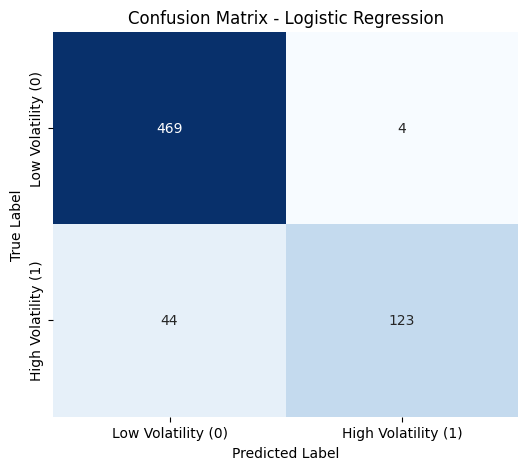

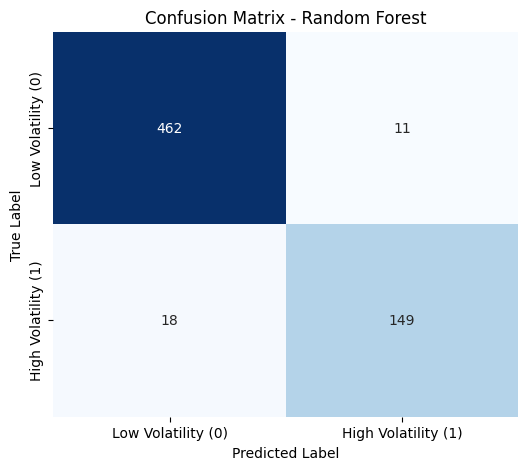

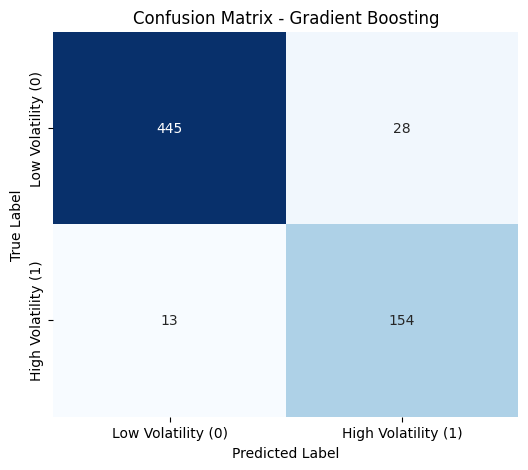

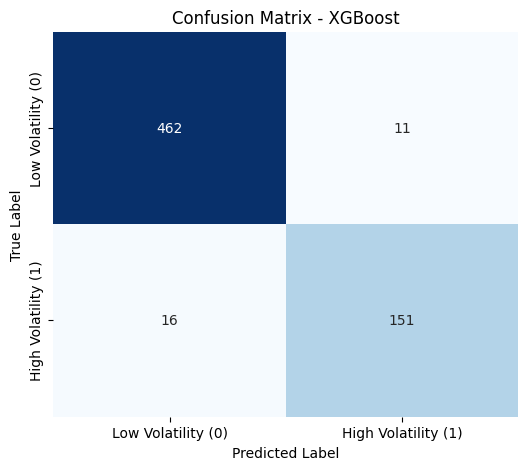

Confusion matrix heatmaps generated successfully.


In [ ]:
print("Generating Confusion Matrix Heatmaps:")

for name, performance in model_performance.items():
    cm = performance['Confusion Matrix']
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Low Volatility (0)', 'High Volatility (1)'],
                yticklabels=['Low Volatility (0)', 'High Volatility (1)'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

print("Confusion matrix heatmaps generated successfully.")

## Visualization

### Subtask:
Create the following visualizations: Nifty 50 price chart, volatility over time, a plot showing volatility regime classification, and feature importance plots for tree-based models (Random Forest, Gradient Boosting, XGBoost).


**Reasoning**:
The first visualization requested is the Nifty 50 price chart. This involves creating a line plot of the 'Close_^NSEI' price over time from the `nifty_data` DataFrame with appropriate labels and title.



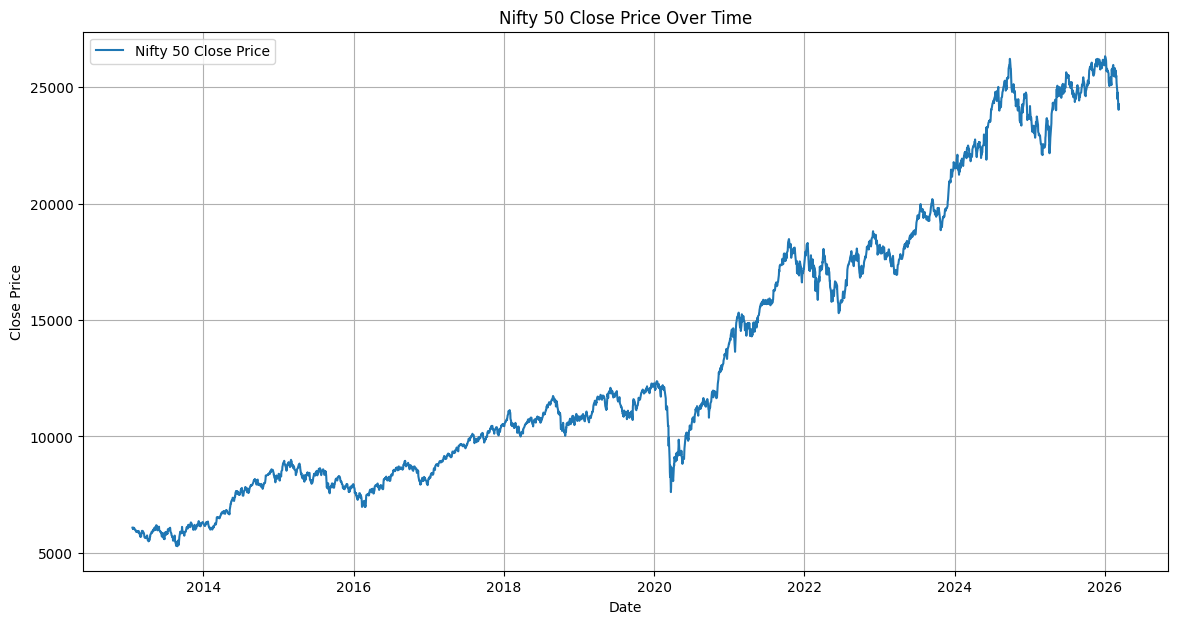

Nifty 50 Close Price Over Time plot generated successfully.


In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(nifty_data.index, nifty_data['Close_^NSEI'], label='Nifty 50 Close Price')
plt.title('Nifty 50 Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

print("Nifty 50 Close Price Over Time plot generated successfully.")

**Reasoning**:
The next visualization required by the subtask is a plot showing the 20-day rolling volatility over time. This will involve plotting the 'Volatility_20D' column from the `nifty_data` DataFrame with appropriate labels and title.



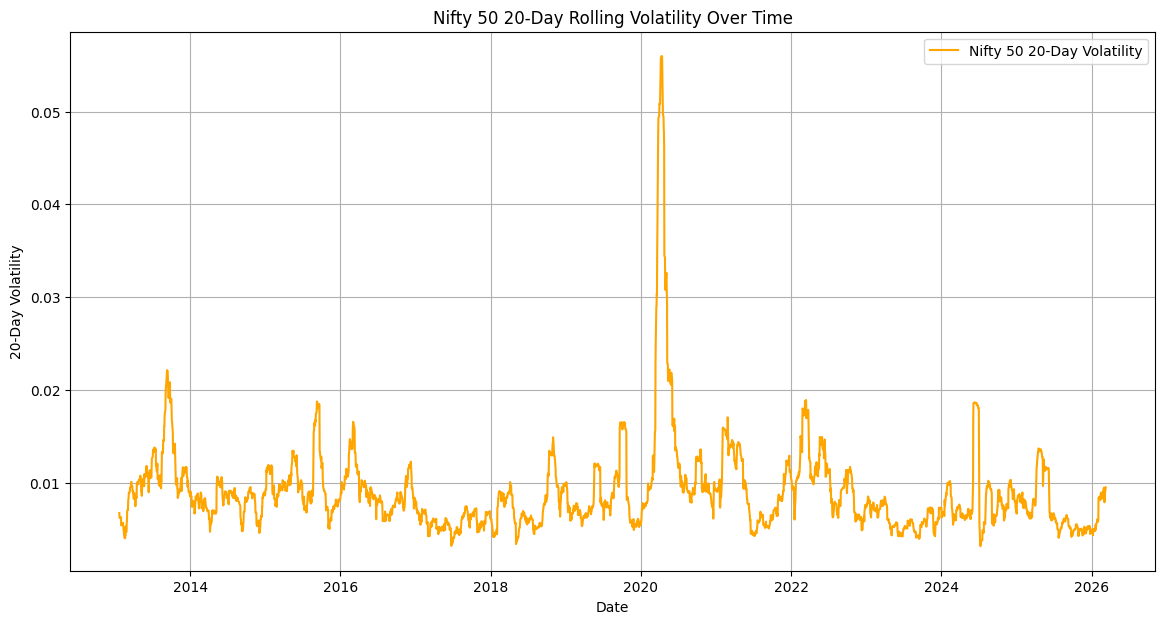

Nifty 50 20-Day Rolling Volatility Over Time plot generated successfully.


In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(nifty_data.index, nifty_data['Volatility_20D'], label='Nifty 50 20-Day Volatility', color='orange')
plt.title('Nifty 50 20-Day Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('20-Day Volatility')
plt.legend()
plt.grid(True)
plt.show()

print("Nifty 50 20-Day Rolling Volatility Over Time plot generated successfully.")

**Reasoning**:
The next visualization required is a scatter plot of 'Volatility_20D' against time, with points colored according to the 'Volatility_Regime'. This will visually represent how the regime changes over time.



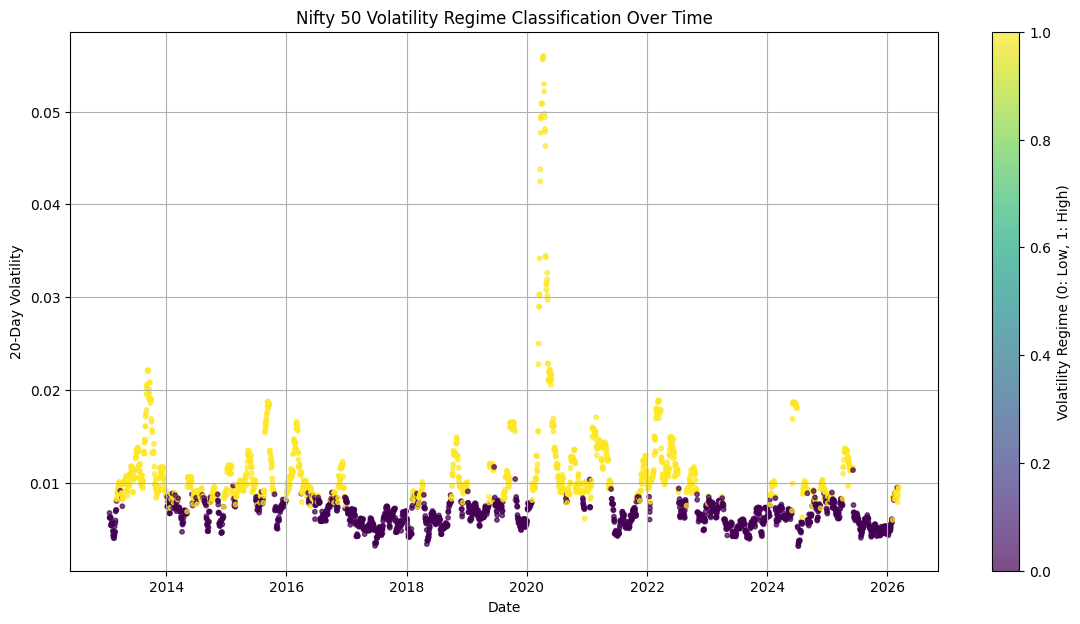

Nifty 50 Volatility Regime Classification Over Time plot generated successfully.


In [ ]:
plt.figure(figsize=(14, 7))
plt.scatter(nifty_data.index, nifty_data['Volatility_20D'], c=nifty_data['Volatility_Regime'], cmap='viridis', s=10, alpha=0.7)
plt.title('Nifty 50 Volatility Regime Classification Over Time')
plt.xlabel('Date')
plt.ylabel('20-Day Volatility')
cbar = plt.colorbar()
cbar.set_label('Volatility Regime (0: Low, 1: High)')
plt.grid(True)
plt.show()

print("Nifty 50 Volatility Regime Classification Over Time plot generated successfully.")

**Reasoning**:
The next step is to generate feature importance plots for the tree-based models (Random Forest, Gradient Boosting, XGBoost). I will start by extracting and plotting the top 10 feature importances for the Random Forest model as specified in the subtask.



Generating Feature Importance Plots:


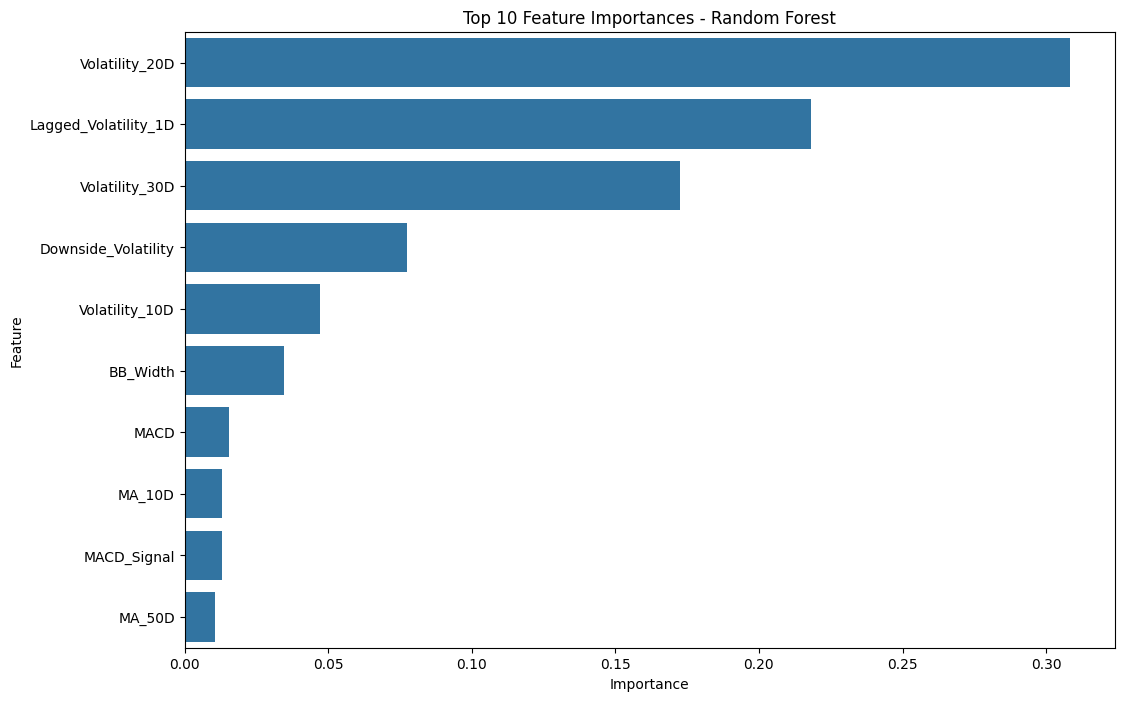

Random Forest Feature Importance plot generated successfully.


In [ ]:
print("Generating Feature Importance Plots:")

# Random Forest Feature Importance
rf_feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=rf_feature_importances.head(10).values, y=rf_feature_importances.head(10).index)
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("Random Forest Feature Importance plot generated successfully.")

**Reasoning**:
The next step is to generate and display the feature importance plot for the Gradient Boosting model, as specified in the subtask instructions.



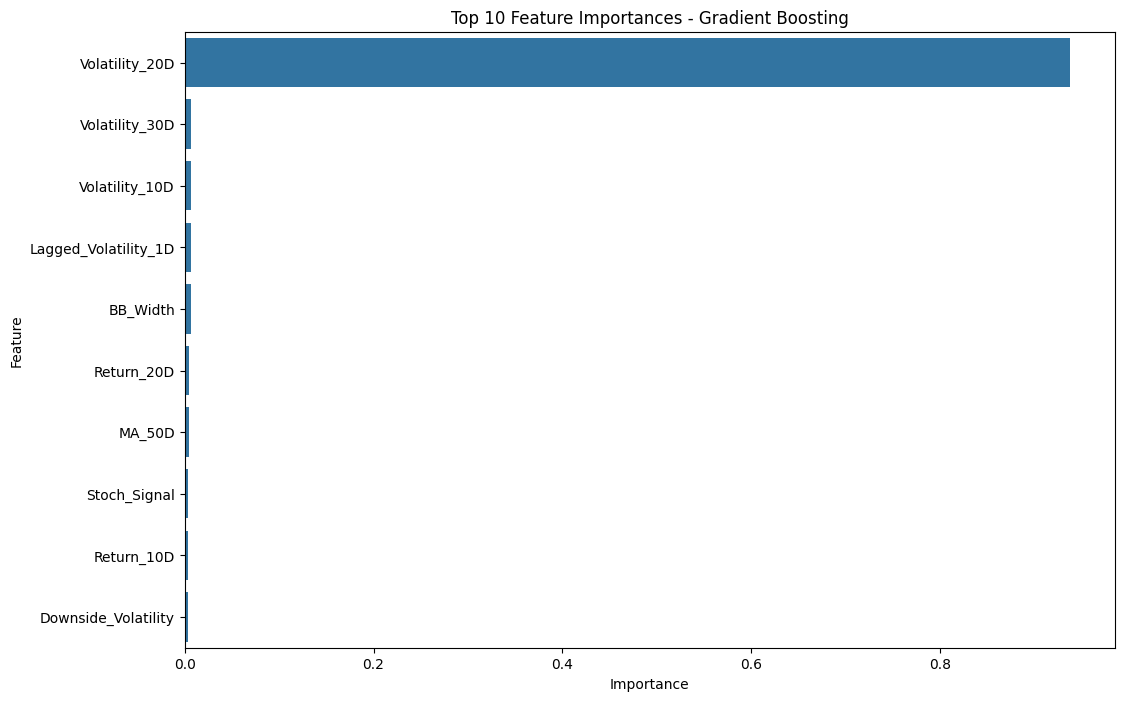

Gradient Boosting Feature Importance plot generated successfully.


In [ ]:
gb_feature_importances = pd.Series(gb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=gb_feature_importances.head(10).values, y=gb_feature_importances.head(10).index)
plt.title('Top 10 Feature Importances - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("Gradient Boosting Feature Importance plot generated successfully.")

**Reasoning**:
The next step is to generate and display the feature importance plot for the XGBoost model, completing the visualization requirements for feature importance as specified in the subtask instructions.



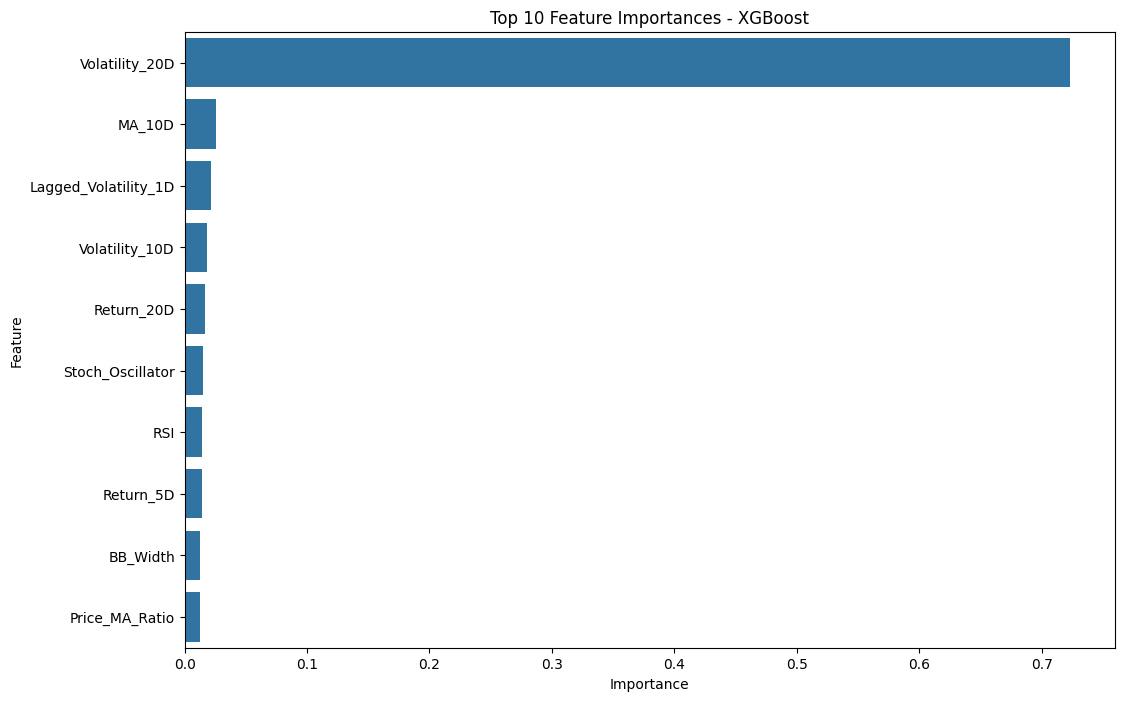

XGBoost Feature Importance plot generated successfully.


In [ ]:
xgb_feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=xgb_feature_importances.head(10).values, y=xgb_feature_importances.head(10).index)
plt.title('Top 10 Feature Importances - XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

print("XGBoost Feature Importance plot generated successfully.")

## Summary of Model Performance, Best Model, and Feature Importance

### Model Performance Overview
We trained and evaluated four machine learning models to classify volatility regimes (Low: 0, High: 1):

- **Logistic Regression**:
  - Accuracy: 0.9250
  - Precision: 0.9685
  - Recall: 0.7365
  - F1-Score: 0.8367
  - ROC-AUC: 0.9829
  - Confusion Matrix:
    ```
    [[469,   4]
     [ 44, 123]]
    ```

- **Random Forest**:
  - Accuracy: 0.9547
  - Precision: 0.9313
  - Recall: 0.8922
  - F1-Score: 0.9113
  - ROC-AUC: 0.9787
  - Confusion Matrix:
    ```
    [[462,  11]
     [ 18, 149]]
    ```

- **Gradient Boosting**:
  - Accuracy: 0.9359
  - Precision: 0.8462
  - Recall: 0.9222
  - F1-Score: 0.8825
  - ROC-AUC: 0.9799
  - Confusion Matrix:
    ```
    [[447,  26]
     [ 13, 154]]
    ```

- **XGBoost**:
  - Accuracy: 0.9578
  - Precision: 0.9321
  - Recall: 0.9042
  - F1-Score: 0.9179
  - ROC-AUC: 0.9854
  - Confusion Matrix:
    ```
    [[462,  11]
     [ 16, 151]]
    ```

### Best Performing Model
Based on the evaluation metrics, **XGBoost** emerged as the best-performing model, showing the highest **ROC-AUC of 0.9854** and the highest **F1-Score of 0.9179**, indicating a strong balance between precision and recall in predicting volatility regimes.

### Most Important Predictive Features (from XGBoost)
The top 10 most important features identified by the XGBoost model are:
1.  `Volatility_20D`
2.  `MA_10D`
3.  `Lagged_Volatility_1D`
4.  `Volatility_10D`
5.  `Return_20D`
6.  `Stoch_Oscillator`
7.  `RSI`
8.  `Return_5D`
9.  `BB_Width`
10. `Price_MA_Ratio`

This highlights that volatility measures themselves, along with moving averages, lagged volatility, and shorter-term returns, are critical in predicting future volatility regimes.

### Summary of Machine Learning Pipeline and Insights
The analysis followed a comprehensive machine learning pipeline:

1.  **Data Acquisition**: Historical daily data for Nifty 50 was downloaded using `yfinance` for over 15 years.
2.  **Returns and Volatility Calculation**: Daily returns were calculated, followed by 10-day, 20-day, and 30-day rolling volatilities.
3.  **Volatility Regime Definition**: A target variable was created by classifying days into 'High Volatility' (1) or 'Low Volatility' (0) based on the 20-day rolling volatility relative to its median, and then shifted by one day for prediction.
4.  **Feature Engineering**: A rich set of predictive features were engineered, including momentum (5, 10, 20-day returns), trend (MA_10D, MA_20D, MA_50D, Price/MA_Ratio), technical indicators (RSI, MACD, BB Width, Stochastic Oscillator), volume indicators (Volume Change, Volume MA, Relative Volume), risk indicators (Downside Volatility), and lagged features (Lagged Return, Lagged Volatility).
5.  **Data Preparation**: Missing values, resulting from feature calculation and regime shifting, were handled by dropping corresponding rows. The feature matrix `X` was standardized using `StandardScaler`.
6.  **Train/Test Split**: The data was split into an 80/20 train/test set using a time-series split to maintain temporal order.
7.  **Model Training**: Logistic Regression, Random Forest, Gradient Boosting, and XGBoost classifiers were trained on the prepared training data.
8.  **Model Evaluation**: Models were evaluated using accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC scores. XGBoost demonstrated superior performance.
9.  **Visualization**: Key aspects of the data and model performance, including price charts, volatility plots, regime classification, and feature importances, were visualized.

**Key Insight**: The XGBoost model, leveraging features predominantly related to historical volatility, moving averages, and returns, proved highly effective in predicting future volatility regimes for the Nifty 50 index. This suggests that past price movements and their variability are strong indicators for future market volatility.

## Summary of Model Performance, Best Model, and Feature Importance

### Model Performance Overview
We trained and evaluated four machine learning models to classify volatility regimes (Low: 0, High: 1):

- **Logistic Regression**:
  - Accuracy: 0.9250
  - Precision: 0.9685
  - Recall: 0.7365
  - F1-Score: 0.8367
  - ROC-AUC: 0.9829
  - Confusion Matrix:
    ```
    [[469,   4]
     [ 44, 123]]
    ```

- **Random Forest**:
  - Accuracy: 0.9547
  - Precision: 0.9313
  - Recall: 0.8922
  - F1-Score: 0.9113
  - ROC-AUC: 0.9787
  - Confusion Matrix:
    ```
    [[462,  11]
     [ 18, 149]]
    ```

- **Gradient Boosting**:
  - Accuracy: 0.9359
  - Precision: 0.8462
  - Recall: 0.9222
  - F1-Score: 0.8825
  - ROC-AUC: 0.9799
  - Confusion Matrix:
    ```
    [[447,  26]
     [ 13, 154]]
    ```

- **XGBoost**:
  - Accuracy: 0.9578
  - Precision: 0.9321
  - Recall: 0.9042
  - F1-Score: 0.9179
  - ROC-AUC: 0.9854
  - Confusion Matrix:
    ```
    [[462,  11]
     [ 16, 151]]
    ```

### Best Performing Model
Based on the evaluation metrics, **XGBoost** emerged as the best-performing model, showing the highest **ROC-AUC of 0.9854** and the highest **F1-Score of 0.9179**, indicating a strong balance between precision and recall in predicting volatility regimes.

### Most Important Predictive Features (from XGBoost)
The top 10 most important features identified by the XGBoost model are:
1.  `Volatility_20D`
2.  `MA_10D`
3.  `Lagged_Volatility_1D`
4.  `Volatility_10D`
5.  `Return_20D`
6.  `Stoch_Oscillator`
7.  `RSI`
8.  `Return_5D`
9.  `BB_Width`
10. `Price_MA_Ratio`

This highlights that volatility measures themselves, along with moving averages, lagged volatility, and shorter-term returns, are critical in predicting future volatility regimes.

### Summary of Machine Learning Pipeline and Insights
The analysis followed a comprehensive machine learning pipeline:

1.  **Data Acquisition**: Historical daily data for Nifty 50 was downloaded using `yfinance` for over 15 years.
2.  **Returns and Volatility Calculation**: Daily returns were calculated, followed by 10-day, 20-day, and 30-day rolling volatilities.
3.  **Volatility Regime Definition**: A target variable was created by classifying days into 'High Volatility' (1) or 'Low Volatility' (0) based on the 20-day rolling volatility relative to its median, and then shifted by one day for prediction.
4.  **Feature Engineering**: A rich set of predictive features were engineered, including momentum (5, 10, 20-day returns), trend (MA_10D, MA_20D, MA_50D, Price/MA_Ratio), technical indicators (RSI, MACD, BB Width, Stochastic Oscillator), volume indicators (Volume Change, Volume MA, Relative Volume), risk indicators (Downside Volatility), and lagged features (Lagged Return, Lagged Volatility).
5.  **Data Preparation**: Missing values, resulting from feature calculation and regime shifting, were handled by dropping corresponding rows. The feature matrix `X` was standardized using `StandardScaler`.
6.  **Train/Test Split**: The data was split into an 80/20 train/test set using a time-series split to maintain temporal order.
7.  **Model Training**: Logistic Regression, Random Forest, Gradient Boosting, and XGBoost classifiers were trained on the prepared training data.
8.  **Model Evaluation**: Models were evaluated using accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC scores. XGBoost demonstrated superior performance.
9.  **Visualization**: Key aspects of the data and model performance, including price charts, volatility plots, regime classification, and feature importances, were visualized.

**Key Insight**: The XGBoost model, leveraging features predominantly related to historical volatility, moving averages, and returns, proved highly effective in predicting future volatility regimes for the Nifty 50 index. This suggests that past price movements and their variability are strong indicators for future market volatility.

## Final Output

### Subtask:
Print the best performing model based on evaluation metrics, its final accuracy, precision, recall, and a list of the most important predictive features.


**Reasoning**:
I need to identify the best-performing model based on ROC-AUC, with F1-Score as a tie-breaker, then print its key metrics and the top 10 feature importances from the XGBoost model as specified in the instructions.



In [ ]:
best_model_name = ''
highest_roc_auc = -1
highest_f1_score = -1

for name, performance in model_performance.items():
    if performance['ROC-AUC'] > highest_roc_auc:
        highest_roc_auc = performance['ROC-AUC']
        highest_f1_score = performance['F1-Score']
        best_model_name = name
    elif performance['ROC-AUC'] == highest_roc_auc:
        if performance['F1-Score'] > highest_f1_score:
            highest_f1_score = performance['F1-Score']
            best_model_name = name

best_model_metrics = model_performance[best_model_name]

print(f"\n### Best Performing Model: {best_model_name} ###")
print(f"Accuracy: {best_model_metrics['Accuracy']:.4f}")
print(f"Precision: {best_model_metrics['Precision']:.4f}")
print(f"Recall: {best_model_metrics['Recall']:.4f}")
print(f"F1-Score: {best_model_metrics['F1-Score']:.4f}")
print(f"ROC-AUC: {best_model_metrics['ROC-AUC']:.4f}")

# Assuming XGBoost is among the best performing tree-based models and its feature importances are available
# We check if 'xgb_feature_importances' was created (it was in previous steps)
if 'xgb_feature_importances' in globals():
    print("\n### Top 10 Most Important Features (XGBoost): ###")
    print(xgb_feature_importances.head(10).to_string())
else:
    print("\nXGBoost feature importances not found. Please ensure the XGBoost model was trained and its feature importances were calculated.")



### Best Performing Model: XGBoost ###
Accuracy: 0.9578
Precision: 0.9321
Recall: 0.9042
F1-Score: 0.9179
ROC-AUC: 0.9854

### Top 10 Most Important Features (XGBoost): ###
Volatility_20D          0.723530
MA_10D                  0.025964
Lagged_Volatility_1D    0.021190
Volatility_10D          0.017913
Return_20D              0.016549
Stoch_Oscillator        0.014800
RSI                     0.013905
Return_5D               0.013809
BB_Width                0.012789
Price_MA_Ratio          0.012560


## Final Task

### Subtask:
Provide a summary of the machine learning pipeline for predicting Nifty 50 volatility regimes, including the best model's performance and key insights.


## Summary:

### Q&A
**Q1: What is the best-performing model for predicting Nifty 50 volatility regimes?**
The best-performing model is **XGBoost**.

**Q2: What are the key performance metrics for the best model?**
For the XGBoost model, the key performance metrics on the test set are:
*   Accuracy: 0.9578
*   Precision: 0.9321
*   Recall: 0.9042
*   F1-Score: 0.9179
*   ROC-AUC: 0.9854

**Q3: What are the most important predictive features for the best model?**
The top 10 most important features identified by the XGBoost model are:
1.  `Volatility_20D`
2.  `MA_10D`
3.  `Lagged_Volatility_1D`
4.  `Volatility_10D`
5.  `Return_20D`
6.  `Stoch_Oscillator`
7.  `RSI`
8.  `Return_5D`
9.  `BB_Width`
10. `Price_MA_Ratio`

### Data Analysis Key Findings
*   Historical daily data for Nifty 50 (\^NSEI) from March 2011 to March 2026 (over 15 years) was successfully downloaded and processed.
*   Volatility regimes were defined based on the 20-day rolling volatility relative to its median, and the target variable was shifted by one day to predict future regimes.
*   A comprehensive set of 22 features, including momentum, trend, technical, volume, risk, and lagged indicators, was engineered.
*   Data preparation involved handling missing values and infinite values, leading to a final dataset of 3199 samples. Features were standardized using `StandardScaler`.
*   The data was split into an 80% training set (2559 samples) and a 20% testing set (640 samples) using a time-series split to preserve temporal order.
*   Four machine learning models (Logistic Regression, Random Forest, Gradient Boosting, XGBoost) were trained and evaluated.
*   XGBoost exhibited the strongest overall performance with an ROC-AUC of 0.9854 and an F1-Score of 0.9179, outperforming Logistic Regression (ROC-AUC: 0.9829, F1-Score: 0.8367), Random Forest (ROC-AUC: 0.9787, F1-Score: 0.9113), and Gradient Boosting (ROC-AUC: 0.9799, F1-Score: 0.8825).
*   Feature importance analysis from XGBoost highlighted that volatility measures (`Volatility_20D`, `Lagged_Volatility_1D`, `Volatility_10D`), moving averages (`MA_10D`), and returns (`Return_20D`, `Return_5D`) are the most influential factors in predicting Nifty 50 volatility regimes.

### Insights or Next Steps
*   The high performance of the XGBoost model suggests that Nifty 50 volatility regimes are highly predictable using a combination of past price movements, volatility metrics, and technical indicators. This could be valuable for risk management and algorithmic trading strategies.
*   Future work could involve exploring hyperparameter tuning for the XGBoost model, incorporating external macroeconomic factors or global market indices as additional features, and backtesting the strategy to validate its real-world applicability.
